<a href="https://colab.research.google.com/github/yalini154/1/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [3]:
dataset = load_breast_cancer()

In [4]:
sns.set_style('dark')

import matplotlib as mpl

mpl.style.use(['https://gist.githubusercontent.com/BrendanMartin/01e71bb9550774e2ccff3af7574c0020/raw/6fa9681c7d0232d34c9271de9be150e584e606fe/lds_default.mplstyle'])

mpl.rcParams.update({"figure.figsize": (8,6), "axes.titlepad": 22.0})

In [5]:
print('Target variable  : ', dataset['target_names'])

Target variable  :  ['malignant' 'benign']


In [6]:
(unique, counts) = np.unique(dataset['target'], return_counts=True)

In [7]:
print('Unique values of the target variable', unique)
print('Counts of the target variable :', counts)

Unique values of the target variable [0 1]
Counts of the target variable : [212 357]


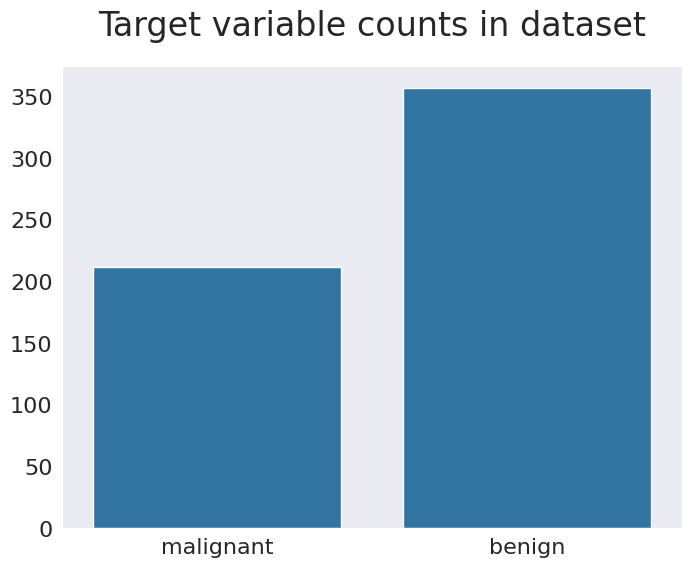

In [9]:
sns.barplot(x=dataset['target_names'], y=counts)
plt.title('Target variable counts in dataset')
plt.show()

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_blobs

In [12]:
X, Y = make_blobs(n_samples=50, centers=2, random_state=0,
                  cluster_std=0.60)

In [13]:
clf = SGDClassifier(loss="hinge", alpha=0.01, max_iter=200)

In [14]:
clf.fit(X, Y)

SGDClassifier(alpha=0.01, max_iter=200)

In [15]:
xx = np.linspace(-1, 5, 10)
yy = np.linspace(-1, 5, 10)

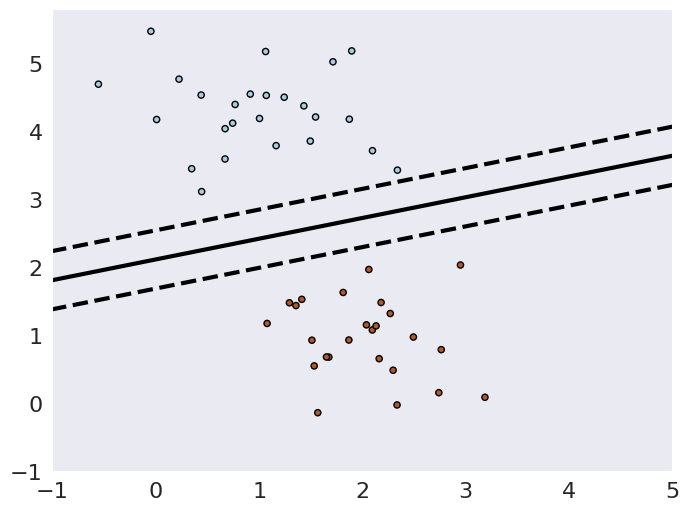

In [16]:
X1, X2 = np.meshgrid(xx, yy)
Z = np.empty(X1.shape)
for (i, j), val in np.ndenumerate(X1):
  x1 = val
  x2 = X2[i, j]
  p = clf.decision_function([[x1, x2]])
  Z[i, j] = p[0]
levels = [-1.0, 0.0, 1.0]
linestyles = ['dashed', 'solid', 'dashed']
color = 'k'
plt.contour(X1, X2, Z, levels, colors=color, linestyles=linestyles)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired, edgecolors='black', s=20)

plt.show()